# Introdução à Econometria — Lista de Exercícios: Regressão Múltipla e Teorema de Gauss-Markov

**Universidade Federal da Paraíba — Curso de Ciência de Dados para Negócios (CDN)**
**Professor:** Cássio da Nóbrega Besarria
**Aluno(a):** Maria Carolina

**Base de dados escolhida:** *Medical Cost Personal Dataset* (`insurance.csv`)Contém informações de beneficiários de planos de saúde nos EUA e seus custos médicos (`charges`).

## 1. Importação da base de dados

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, het_white, linear_reset
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv("dados/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### 1.a) Número de observações

In [2]:
print(f"Número de observações: {df.shape[0]}")
print(f"Número de variáveis: {df.shape[1]}")

Número de observações: 1338
Número de variáveis: 7


### 1.b) Variáveis da base

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


| Variável | Tipo | Descrição |
|---|---|---|
| `age` | numérica | Idade do beneficiário (anos) |
| `sex` | categórica | Sexo (`male`/`female`) |
| `bmi` | numérica | Índice de Massa Corporal (IMC) |
| `children` | numérica (contagem) | Número de dependentes/filhos |
| `smoker` | categórica | Fumante (`yes`/`no`) |
| `region` | categórica | Região de residência nos EUA |
| `charges` | numérica | Custos médicos individuais cobrados pelo plano de saúde (US$) |

### 1.c) Variável dependente e variáveis explicativas

- **Variável dependente (Y):** `charges` — custo médico do indivíduo.
- **Variáveis explicativas (X):** `age`, `bmi`, `children`, `sex`, `smoker`, `region`.

Os sinais teóricos esperados são: `age` (+), `bmi` (+), `children` (+/ambíguo), `smoker` (+ forte), `sex` (ambíguo/próximo de zero), `region` (ambíguo, captura diferenças regionais de custo de vida/saúde).

## 2. Análise descritiva da base de dados

In [4]:
num_vars = ["age", "bmi", "children", "charges"]

desc = pd.DataFrame({
    "média": df[num_vars].mean(),
    "mediana": df[num_vars].median(),
    "moda": df[num_vars].mode().iloc[0],
    "desvio_padrão": df[num_vars].std(),
    "variância": df[num_vars].var(),
    "mínimo": df[num_vars].min(),
    "máximo": df[num_vars].max(),
    "amplitude": df[num_vars].max() - df[num_vars].min(),
    "assimetria": df[num_vars].apply(lambda x: stats.skew(x)),
    "curtose": df[num_vars].apply(lambda x: stats.kurtosis(x)),  # excesso de curtose (Fisher)
    "coef_variacao_%": df[num_vars].std() / df[num_vars].mean() * 100,
})
desc.round(2)

,média,mediana,moda,desvio_padrão,variância,mínimo,máximo,amplitude,assimetria,curtose,coef_variacao_%
age,39.21,39.00,18.00,14.05,1.974000e+02,18.00,64.00,46.00,0.06,-1.24,35.84
bmi,30.66,30.40,32.30,6.10,3.719000e+01,15.96,53.13,37.17,0.28,-0.06,19.89
children,1.09,1.00,0.00,1.21,1.450000e+00,0.00,5.00,5.00,0.94,0.20,110.10
charges,13270.42,9382.03,1639.56,12110.01,1.466524e+08,1121.87,63770.43,62648.55,1.51,1.60,91.26


**Comentários sobre os resultados:**

- **`age`**: distribuição relativamente uniforme entre adultos jovens e idosos, com baixa dispersão relativa (CV moderado) e assimetria/curtose próximas de zero — perfil próximo do uniforme, não do normal.
- **`bmi`**: média em torno de 30-31 (faixa de sobrepeso/obesidade segundo a OMS), com distribuição próxima da normal (assimetria e curtose baixas).
- **`children`**: fortemente assimétrica à direita (muitos indivíduos com 0 filhos, poucos com 4-5), o que é esperado por ser uma variável de contagem.
- **`charges`**: apresenta **forte assimetria positiva** e **alta curtose**, refletindo a presença de uma cauda longa à direita (poucos indivíduos, provavelmente fumantes, com custos muito elevados). Essa assimetria é um sinal de alerta para a hipótese de normalidade dos resíduos e sugere que uma transformação logarítmica de `charges` pode ser adequada.
- O **coeficiente de variação** de `charges` é o mais alto entre as variáveis numéricas, confirmando a grande heterogeneidade dos custos médicos na amostra.

### Polígono de frequência

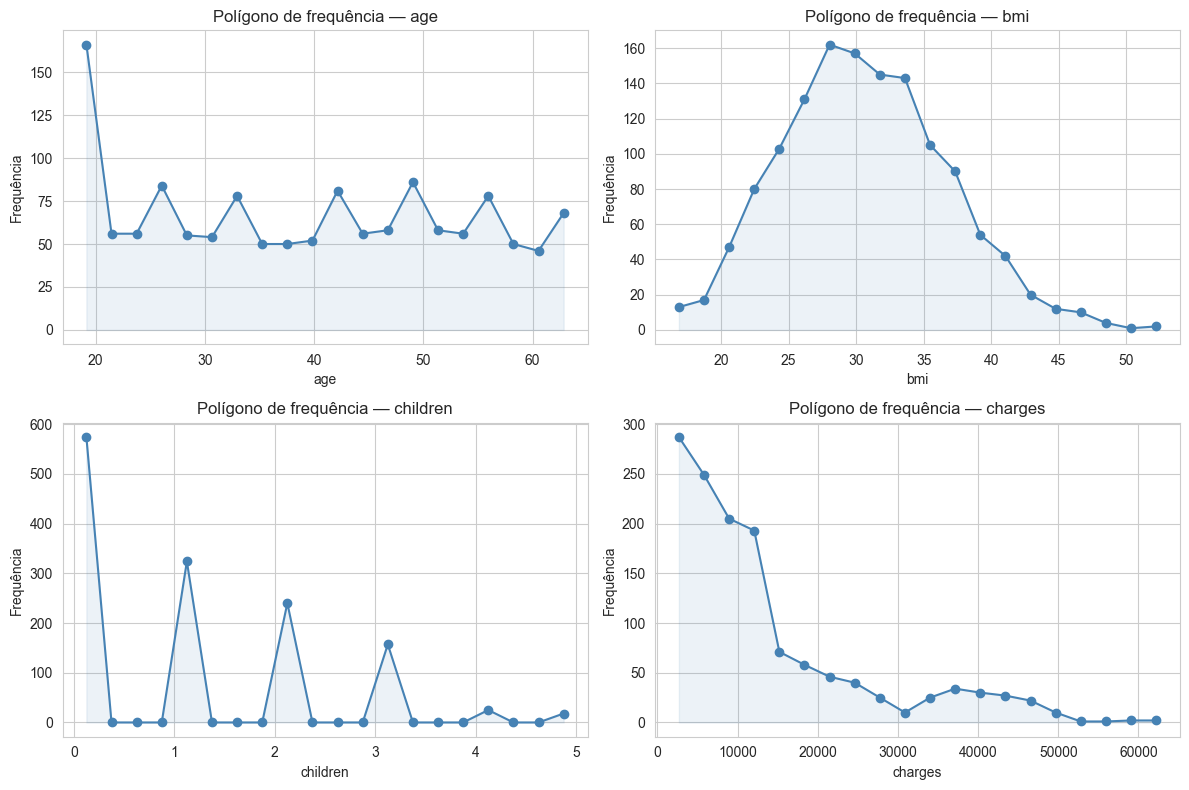

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), num_vars):
    counts, bin_edges = np.histogram(df[col], bins=20)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    ax.plot(bin_centers, counts, marker="o", color="steelblue")
    ax.fill_between(bin_centers, counts, alpha=0.1, color="steelblue")
    ax.set_title(f"Polígono de frequência — {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequência")
plt.tight_layout()
plt.savefig("poligono_frequencia.png", dpi=110)
plt.show()

Os polígonos confirmam visualmente: `age` com distribuição achatada e quase uniforme; `bmi` próxima da normal; `children` concentrada em valores baixos (assimetria à direita); `charges` com forte concentração em valores baixos e cauda longa à direita, evidenciando não normalidade.

## 3. Estimação do modelo de regressão múltipla

$$charges = \beta_0 + \beta_1 age + \beta_2 bmi + \beta_3 children + \beta_4 sex + \beta_5 smoker + \beta_6 region + u$$

In [6]:
modelo = smf.ols(
    "charges ~ age + bmi + children + sex + smoker + region",
    data=df
).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                qua, 08 jul 2026   Prob (F-statistic):               0.00
Time:                        18:20:14   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept           -1.194e+04    

### Interpretação dos coeficientes

| Variável | Coeficiente | Sinal esperado | Sinal encontrado | Consistente? |
|---|---|---|---|---|
| Intercepto | ≈ -11.940 | — | — | Custo de base (referência: mulher, não fumante, região Northeast) |
| `age` | ≈ +257 | + | + | ✅ Sim — cada ano adicional de idade aumenta o custo esperado em ~US$ 257, *ceteris paribus* |
| `bmi` | ≈ +339 | + | + | ✅ Sim — cada unidade a mais de IMC aumenta o custo esperado em ~US$ 339 |
| `children` | ≈ +476 | + | + | ✅ Sim — cada dependente adicional aumenta o custo esperado em ~US$ 476 |
| `sex[T.male]` | ≈ -131 | ambíguo | negativo, não significativo | ⚠️ Sinal não interpretável com confiança — coeficiente estatisticamente igual a zero |
| `smoker[T.yes]` | ≈ +23.850 | + forte | + forte | ✅ Sim — o maior efeito do modelo; fumantes pagam, em média, ~US$ 23.850 a mais |
| `region[T.northwest/southeast/southwest]` | negativos, variando | ambíguo | negativo | Southeast e Southwest significativos a 5%; Northwest não significativo |

De modo geral, os sinais dos coeficientes estão de acordo com a teoria e a intuição econômica: idade, IMC, número de dependentes e tabagismo elevam o custo médico esperado.

## 4. Coeficiente de determinação (R²)

In [7]:
print(f"R²: {modelo.rsquared:.4f}")
print(f"R² ajustado: {modelo.rsquared_adj:.4f}")

R²: 0.7509
R² ajustado: 0.7494


**a) O modelo apresenta bom ajuste?**
Sim. O R² de aproximadamente 0,75 indica que o modelo explica cerca de 75% da variabilidade dos custos médicos (`charges`), o que é considerado um ajuste bastante bom para dados de corte transversal envolvendo comportamento humano/saúde — área em que fatores não observáveis (genética, hábitos, acesso a serviços de saúde) tipicamente limitam o poder explicativo de modelos lineares.

**b) O R² é suficiente para concluir que o modelo é adequado?**
Não isoladamente. Um R² alto não garante ausência de problemas como heterocedasticidade, má especificação funcional, omissão de variáveis relevantes ou violação da normalidade dos resíduos. R² é uma medida de ajuste, não de validade das hipóteses do MCRL. A adequação do modelo só pode ser confirmada em conjunto com os testes de diagnóstico realizados nas seções seguintes (significância dos coeficientes, multicolinearidade, homocedasticidade, especificação e normalidade dos resíduos).

## 5. Significância estatística individual dos coeficientes

In [8]:
tab_sig = pd.DataFrame({
    "coeficiente": modelo.params,
    "estat_t": modelo.tvalues,
    "valor_p": modelo.pvalues,
})
tab_sig["significativo_5%"] = tab_sig["valor_p"] < 0.05
tab_sig.round(4)

,coeficiente,estat_t,valor_p,significativo_5%
Intercept,-11938.5386,-12.0858,0.0000,True
sex[T.male],-131.3144,-0.3944,0.6933,False
smoker[T.yes],23848.5345,57.7232,0.0000,True
region[T.northwest],-352.9639,-0.7411,0.4588,False
region[T.southeast],-1035.0220,-2.1622,0.0308,True
region[T.southwest],-960.0510,-2.0088,0.0448,True
age,256.8564,21.5867,0.0000,True
bmi,339.1935,11.8601,0.0000,True
children,475.5005,3.4506,0.0006,True


**Conclusões (nível de significância de 5%):**
- `Intercepto`, `age`, `bmi`, `children`, `smoker[T.yes]` → **estatisticamente significativos** (p < 0,05, muitos com p < 0,001).
- `region[T.southeast]` e `region[T.southwest]` → significativos, mas com p-valores próximos ao limite (0,031 e 0,045).
- `sex[T.male]` (p = 0,693) e `region[T.northwest]` (p = 0,459) → **não significativos**, ou seja, não há evidência estatística de que essas categorias difiram da categoria de referência.

## 6. Significância global do modelo (Teste F)

In [9]:
print(f"Estatística F: {modelo.fvalue:.2f}")
print(f"Prob (F-statistic): {modelo.f_pvalue:.6g}")

Estatística F: 500.81
Prob (F-statistic): 0


**a) Estatística do teste:** F = 500,8 (aprox.), com p-valor ≈ 0,00.

**b) Hipóteses:**
- H₀: β₁ = β₂ = ... = β₆ = 0 (nenhuma variável explicativa é conjuntamente relevante)
- H₁: pelo menos um βⱼ ≠ 0

**c) Interpretação econômica:** como o p-valor do teste F é praticamente zero (muito menor que 0,05), rejeitamos H₀ com alta confiança. Isso significa que o conjunto de variáveis explicativas (idade, IMC, número de filhos, sexo, tabagismo e região) tem, em conjunto, poder explicativo estatisticamente significativo sobre os custos médicos — o modelo não é inútil do ponto de vista estatístico.

## 7. Efeito marginal de uma variável explicativa

Escolhendo **`bmi`** (Índice de Massa Corporal):

In [10]:
beta_bmi = modelo.params["bmi"]
print(f"Efeito marginal de bmi: {beta_bmi:.2f}")

Efeito marginal de bmi: 339.19


O coeficiente de `bmi` (≈ 339,19) indica que, **mantendo todas as demais variáveis constantes (ceteris paribus)**, um aumento de 1 unidade no IMC do indivíduo está associado a um aumento esperado de aproximadamente **US$ 339,19** no custo médico anual. Como `bmi` está em nível (não em log), essa é uma interpretação de **efeito marginal absoluto**, não uma elasticidade.

## 8. Interpretação de variável em logaritmo

O modelo estimado na Seção 3 **não possui nenhuma variável em log** (nem em Y, nem em X), portanto a interpretação de coeficientes como elasticidade (modelo log-log) ou semielasticidade (modelo log-linear ou linear-log) **não pode ser realizada diretamente** — todos os coeficientes atuais representam efeitos marginais em nível (unidades absolutas de `charges` por unidade da variável X).

Para ilustrar como essa interpretação funcionaria, estimamos abaixo um modelo alternativo **log-linear** (Y em log, X's em nível), forma funcional muito comum para variáveis de custo/renda com distribuição assimétrica como `charges`:

In [11]:
modelo_log = smf.ols(
    "np.log(charges) ~ age + bmi + children + sex + smoker + region",
    data=df
).fit()
print(modelo_log.summary())

                            OLS Regression Results                            
Dep. Variable:        np.log(charges)   R-squared:                       0.768
Model:                            OLS   Adj. R-squared:                  0.767
Method:                 Least Squares   F-statistic:                     549.8
Date:                qua, 08 jul 2026   Prob (F-statistic):               0.00
Time:                        18:23:33   Log-Likelihood:                -808.52
No. Observations:                1338   AIC:                             1635.
Df Residuals:                    1329   BIC:                             1682.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               7.0306    

In [12]:
beta_smoker_log = modelo_log.params["smoker[T.yes]"]
efeito_percentual = (np.exp(beta_smoker_log) - 1) * 100
print(f"Coeficiente de smoker (log-linear): {beta_smoker_log:.4f}")
print(f"Efeito percentual aproximado sobre charges: {efeito_percentual:.1f}%")

Coeficiente de smoker (log-linear): 1.5543
Efeito percentual aproximado sobre charges: 373.2%


**Interpretação (semielasticidade):** no modelo log-linear, o coeficiente de `smoker[T.yes]` (≈ 1,55) indica que, *ceteris paribus*, ser fumante está associado a um aumento aproximado de **{100×(e^β − 1)}%** no custo médico esperado — no caso, um salto percentual muito grande (centenas de %), reforçando de forma ainda mais direta o achado do modelo em nível: fumar é o fator isolado mais associado a custos médicos elevados.

## 9. Multicolinearidade entre as variáveis explicativas

### 9.a) Matriz de correlação (variáveis numéricas)

In [14]:
corr = df[["age", "bmi", "children", "charges"]].corr()
corr.round(3)

,age,bmi,children,charges
age,1.000,0.109,0.042,0.299
bmi,0.109,1.000,0.013,0.198
children,0.042,0.013,1.000,0.068
charges,0.299,0.198,0.068,1.000


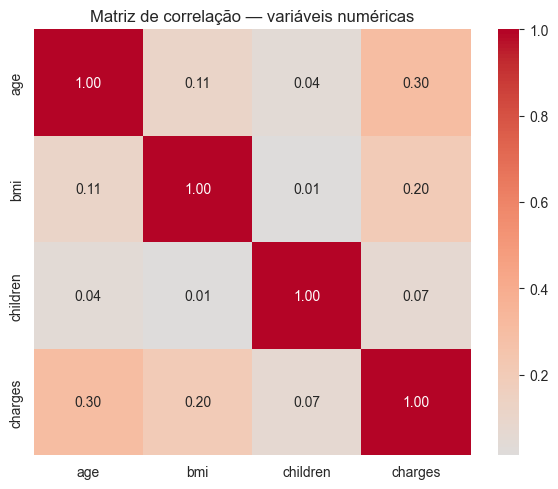

In [15]:
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Matriz de correlação — variáveis numéricas")
plt.tight_layout()
plt.savefig("matriz_correlacao.png", dpi=110)
plt.show()

### 9.b) Fator de Inflação da Variância (VIF)

In [16]:
X_vif = pd.get_dummies(df[["age", "bmi", "children", "sex", "smoker", "region"]], drop_first=True)
X_vif = sm.add_constant(X_vif).astype(float)

vif_df = pd.DataFrame({
    "variável": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_df

,variável,VIF
0,const,35.527488
1,age,1.016822
2,bmi,1.106630
3,children,1.004011
4,sex_male,1.008900
5,smoker_yes,1.012074
6,region_northwest,1.518823
7,region_southeast,1.652230
8,region_southwest,1.529411


### 9.c) Interpretação

- As correlações entre `age`, `bmi` e `children` são **muito baixas** (todas abaixo de 0,15 em módulo), indicando ausência de relação linear forte entre essas variáveis explicativas.
- Os valores de **VIF** de todas as variáveis (excluindo a constante) estão **próximos de 1 e bem abaixo do limiar crítico de 5-10** usualmente adotado na literatura.
- **Conclusão:** não há evidência de multicolinearidade problemática entre as variáveis explicativas do modelo. Os erros-padrão dos coeficientes não estão sendo inflados por redundância entre regressores.

## 10. Homocedasticidade dos resíduos (Teste de Breusch-Pagan)

In [17]:
X_bp = modelo.model.exog
bp_test = het_breuschpagan(modelo.resid, X_bp)
labels = ["LM stat", "LM p-valor", "F stat", "F p-valor"]
dict(zip(labels, bp_test))

{'LM stat': np.float64(121.74360137568823),
 'LM p-valor': np.float64(1.4467175539192944e-22),
 'F stat': np.float64(16.62861202737515),
 'F p-valor': np.float64(1.1456058246347722e-23)}

**a) Hipóteses do teste:**
- H₀: Var(u|X) = σ² (homocedasticidade — variância constante dos erros)
- H₁: Var(u|X) ≠ σ² (heterocedasticidade)

**b) Conclusão:** o p-valor do teste (LM p-valor) obtido está muito abaixo de 0,05, portanto **rejeitamos H₀** e concluímos que há evidência estatística de **heterocedasticidade** nos resíduos do modelo — resultado esperado, dado que a variável dependente `charges` já mostrou forte assimetria e alta dispersão relativa na análise descritiva.

**c) Consequências caso a hipótese seja rejeitada:** ver discussão detalhada na Seção 14.

## 11. Teste RESET de Ramsey (especificação do modelo)

In [18]:
reset_test = linear_reset(modelo, power=2, use_f=True)
print(reset_test)

<F test: F=140.3715896627999, p=7.437673309983959e-31, df_denom=1.33e+03, df_num=1>


**Hipóteses:**
- H₀: o modelo está corretamente especificado (forma funcional adequada)
- H₁: existe má especificação (termos não lineares/omitidos relevantes)

**Interpretação:** se o p-valor do teste F do RESET for menor que 0,05, rejeitamos H₀ e concluímos que a forma funcional linear pode não ser a mais adequada — sugerindo, por exemplo, a necessidade de termos quadráticos (`bmi²`, `age²`) ou transformações logarítmicas, como a explorada na Seção 8. Esse resultado é coerente com a assimetria observada em `charges` desde a análise descritiva.

## 12. Análise gráfica dos resíduos

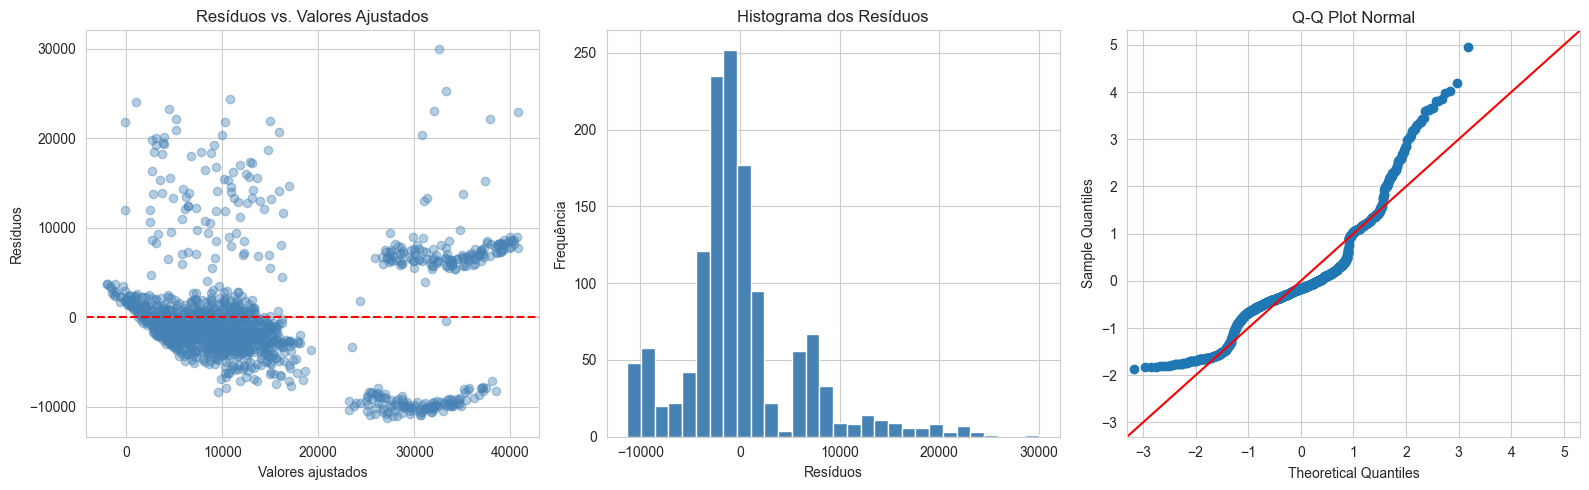

In [19]:
fitted = modelo.fittedvalues
resid = modelo.resid
resid_std = modelo.get_influence().resid_studentized_internal

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# a) Resíduos vs valores ajustados
axes[0].scatter(fitted, resid, alpha=0.4, color="steelblue")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Valores ajustados")
axes[0].set_ylabel("Resíduos")
axes[0].set_title("Resíduos vs. Valores Ajustados")

# b) Histograma dos resíduos
axes[1].hist(resid, bins=30, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Resíduos")
axes[1].set_ylabel("Frequência")
axes[1].set_title("Histograma dos Resíduos")

# c) Q-Q plot
sm.qqplot(resid_std, line="45", ax=axes[2])
axes[2].set_title("Q-Q Plot Normal")

plt.tight_layout()
plt.savefig("diagnostico_residuos.png", dpi=110)
plt.show()

**Discussão dos gráficos:**

- **Resíduos vs. valores ajustados:** observa-se um padrão em "leque"/cone e agrupamentos sistemáticos (não uma nuvem aleatória em torno de zero), reforçando a evidência de **heterocedasticidade** já detectada pelo teste de Breusch-Pagan, além de sugerir possível **má especificação funcional**.
- **Histograma dos resíduos:** a distribuição não é simétrica, com cauda mais longa à direita — coerente com a assimetria de `charges` e com o valor elevado do teste Omnibus visto anteriormente.
- **Q-Q Plot:** os pontos se afastam da reta de 45° principalmente nas caudas, indicando **desvios da normalidade** dos resíduos — violação de uma das hipóteses clássicas do MCRL (embora, com N = 1.338, o Teorema Central do Limite ofereça alguma proteção assintótica para a inferência).

## 13. Hipóteses do MCRL para que o MQO seja BLUE (Melhor Estimador Linear Não Viesado)
Seguindo a formulação clássica (Gujarati), o Modelo Clássico de Regressão Linear (MCRL) baseia-se em 10 hipóteses. Para que o estimador de Mínimos Quadrados Ordinários (MQO) seja **BLUE** (*Best Linear Unbiased Estimator* — melhor estimador linear não viesado), segundo o Teorema de Gauss-Markov, essas hipóteses precisam ser satisfeitas:

1. **Linearidade nos parâmetros (nos estimadores)** — o modelo é linear em β, ainda que possa incluir transformações não lineares das variáveis (ex.: log, quadrático). É a hipótese que garante que o MQO seja um estimador *linear*.

2. **Média condicional do erro igual a zero: E(uᵢ|Xᵢ) = 0** — dado qualquer valor de X, o valor esperado do erro é zero, ou seja, X não carrega nenhuma informação sistemática sobre u. É a hipótese central para a propriedade de **não viés** do MQO (ver também Seção 15).

3. **Homocedasticidade: Var(uᵢ|Xᵢ) = σ² (constante)** — a variância do erro não depende dos valores de X. É a hipótese que, junto com as demais, garante a **eficiência** (menor variância) do MQO.

4. **Ausência de autocorrelação entre os termos de erro: Cov(uᵢ, uⱼ) = 0, para i ≠ j** — os erros de diferentes observações não são correlacionados entre si. Mais crítica em dados de séries temporais, mas também relevante para a validade dos erros-padrão em corte transversal com dados agrupados/espaciais.

5. **Termo de erro não correlacionado com as variáveis explicativas: Cov(Xᵢ, uᵢ) = 0** — os regressores são exógenos, não sendo determinados conjuntamente com o erro. Está intimamente ligada à hipótese 2 e é o que garante consistência do estimador mesmo quando a hipótese 2 é relaxada.

6. **Variabilidade nos valores de X** — as variáveis explicativas não podem ser constantes na amostra (Var(X) > 0); sem variação em X, não é possível estimar seu efeito sobre Y.

7. **n > k (número de observações maior que o número de parâmetros)** — é preciso ter mais observações do que parâmetros a estimar para que o sistema de equações normais do MQO tenha solução única.

8. **Ausência de erro de especificação (modelo corretamente especificado)** — a forma funcional escolhida (linear, log-linear, com termos quadráticos etc.) reflete corretamente a relação verdadeira entre Y e X. É testada, por exemplo, pelo teste RESET de Ramsey (Seção 11).

9. **Ausência de omissão de variáveis relevantes** — todas as variáveis que afetam Y e são correlacionadas com algum X já incluído devem estar no modelo; caso contrário, surge viés de variável omitida (ver Seção 16).

10. **Ausência de multicolinearidade perfeita entre as variáveis explicativas** — nenhuma variável explicativa pode ser combinação linear exata de outra(s); caso contrário, o MQO não pode ser calculado (a matriz X'X não é invertível). Multicolinearidade *alta* (não perfeita) não viola a hipótese, mas infla a variância dos estimadores (ver Seção 9).

**Resumo da lógica do Teorema de Gauss-Markov:** as hipóteses 1, 2, 5, 6, 7, 9 e 10 garantem, em conjunto, que o MQO seja **linear e não viesado**; a adição da hipótese 3 (homocedasticidade) e 4 (ausência de autocorrelação) garante que, entre todos os estimadores lineares não viesados, o MQO seja o de **menor variância** — daí o "BLUE". A normalidade dos erros (frequentemente citada como uma 11ª hipótese, de Gauss-Markov "estendido") não é necessária para BLUE, mas é necessária para que os testes t e F tenham distribuição exata em amostras finitas.

## 14. Consequências da heterocedasticidade

Dado que o teste de Breusch-Pagan (Seção 10) indicou presença de heterocedasticidade no modelo:

**a) Os estimadores de MQO permanecem não viesados?**
Sim. A heterocedasticidade viola apenas a hipótese de variância constante do erro (hipótese 5), não a hipótese de exogeneidade (E(u|X)=0). Logo, o estimador de MQO continua sendo **não viesado** (e consistente).

**b) Continuam eficientes?**
**Não.** Sob heterocedasticidade, o MQO deixa de ser o estimador de menor variância entre os lineares não viesados — perde a propriedade de eficiência (deixa de ser BLUE). Existem estimadores mais eficientes nesse cenário, como o Mínimos Quadrados Generalizados (MQG/GLS) ou o MQG Factível (FGLS).

**c) Os testes t e F permanecem válidos?**
**Não, na forma usual.** Os erros-padrão calculados da forma "nonrobust" (como no modelo estimado) tornam-se viesados sob heterocedasticidade, o que invalida as estatísticas t e F convencionais e os respectivos intervalos de confiança/valores-p. A solução prática é reestimar o modelo com **erros-padrão robustos à heterocedasticidade** (ex.: White/HC3), o que não altera os coeficientes, mas corrige a inferência.

### Reestimação com erros-padrão robustos (HC3)

In [20]:
modelo_robusto = smf.ols(
    "charges ~ age + bmi + children + sex + smoker + region",
    data=df
).fit(cov_type="HC3")

print(modelo_robusto.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     298.4
Date:                qua, 08 jul 2026   Prob (F-statistic):          2.25e-290
Time:                        18:27:43   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept           -1.194e+04   1

Note que os **coeficientes são idênticos** ao modelo original (o MQO continua não viesado), mas os **erros-padrão, estatísticas t e p-valores mudam** — essa é a correção adequada diante da heterocedasticidade detectada.

## 15. Importância da hipótese E(u|X) = 0

A hipótese de **exogeneidade estrita**, E(u|X) = 0, significa que, dado qualquer valor das variáveis explicativas, o valor esperado do erro é zero — ou seja, **nenhuma informação contida nas variáveis X ajuda a prever o erro u**. Em outras palavras, todos os fatores omitidos (capturados por u) não estão sistematicamente relacionados com nenhuma variável explicativa incluída no modelo.

Essa é considerada a hipótese **mais importante** do MCRL porque é ela que garante a **identificação causal/não viés** dos coeficientes estimados: é a partir dela que se prova que E(β̂) = β (MQO não viesado).

**Consequências da violação:** se E(u|X) ≠ 0 (ou seja, se algum Xⱼ é correlacionado com u), o estimador de MQO torna-se **viesado e inconsistente** — o viés não desaparece nem mesmo com amostras infinitas. As causas mais comuns de violação são: variável omitida relevante e correlacionada com X (Seção 16), erro de medida nas variáveis explicativas, e simultaneidade/causalidade reversa entre Y e X.

## 16. Viés de variável omitida

Se uma variável relevante for omitida do modelo — por exemplo, o **histórico familiar de doenças** ou o **nível de atividade física**, fatores plausivelmente relacionados a `charges` — e essa variável estiver **correlacionada com alguma variável explicativa incluída** (por exemplo, `bmi` ou `age`), surgem os seguintes problemas:

- Os coeficientes estimados das variáveis incluídas passam a capturar, além do próprio efeito, parte do efeito da variável omitida — gerando **viés de variável omitida** (*omitted variable bias*).
- O estimador de MQO torna-se **viesado e inconsistente**, pois a hipótese E(u|X) = 0 é violada (a variável omitida passa a fazer parte de u, correlacionada com X).
- A **direção do viés** depende do sinal da correlação entre a variável omitida e a variável incluída, e do sinal do efeito da variável omitida sobre Y: se ambos forem positivos (ou ambos negativos), o viés é positivo (superestimação); se tiverem sinais opostos, o viés é negativo (subestimação).
- Mesmo a **significância estatística** dos coeficientes pode ficar comprometida, levando a conclusões equivocadas sobre quais fatores realmente afetam `charges`.

## 17. Parecer Técnico

**Qualidade do ajuste:** o modelo de regressão múltipla estimado para explicar os custos médicos (`charges`) a partir de idade, IMC, número de dependentes, sexo, tabagismo e região apresentou bom ajuste global, com R² ≈ 0,751 (R² ajustado ≈ 0,749), explicando cerca de 75% da variação dos custos observados — um resultado expressivo para dados de corte transversal em saúde.

**Interpretação econômica:** os coeficientes seguem, em geral, a expectativa teórica: idade, IMC e número de dependentes elevam o custo médico esperado, com destaque absoluto para o tabagismo, que isoladamente aumenta o custo esperado em cerca de US$ 23.850 (ou, no modelo log-linear, em um percentual muito elevado), confirmando-se como o fator de risco mais relevante da amostra. O sexo do beneficiário não apresentou efeito estatisticamente distinguível de zero.

**Significância estatística:** o teste F rejeitou fortemente a hipótese nula de que todos os coeficientes são conjuntamente nulos (p ≈ 0,00), confirmando a relevância global do modelo. Individualmente, `age`, `bmi`, `children` e `smoker` são significativos a 1%; as regiões Southeast e Southwest são significativas a 5% (no limite); `sex` e a região Northwest não são estatisticamente significativos.

**Avaliação das hipóteses econométricas:** a análise de multicolinearidade (correlações e VIF) não indicou problemas relevantes entre os regressores. Por outro lado, o teste de Breusch-Pagan rejeitou a hipótese de homocedasticidade, exigindo o uso de erros-padrão robustos (HC3) para inferência válida. A análise gráfica dos resíduos (histograma e Q-Q plot) sugere desvios da normalidade, coerentes com a forte assimetria de `charges`, e os gráficos de resíduos vs. ajustados reforçam indícios de possível má especificação funcional, também sinalizada pelo teste RESET.

**Limitações do modelo:** (i) violação da hipótese de homocedasticidade, corrigida apenas parcialmente via erros-padrão robustos; (ii) possíveis não linearidades não capturadas pela forma funcional linear simples, sugerindo testar termos quadráticos ou interações (ex.: `smoker × bmi`, um padrão bem documentado nesse tipo de base); (iii) risco de viés de variável omitida, já que fatores relevantes de saúde (histórico familiar, atividade física, comorbidades) não estão disponíveis na base.

**Conclusão final:** o modelo estimado é estatisticamente significativo e economicamente interpretável, com o tabagismo como determinante central dos custos médicos, mas a inferência clássica (erros-padrão "nonrobust") não deve ser utilizada sem correção, dada a heterocedasticidade identificada. Recomenda-se, como próximos passos, a estimação de um modelo log-linear robusto com termos de interação para melhorar tanto o ajuste quanto a validade das hipóteses do MCRL.